## Multiplayer Proxy Failure _ Data analysis


In [1]:

import numpy as np
import pandas as pd
import matplotlib 

## Open the file

In [4]:
# use pandas to read filtered data
#df = pd.read_csv('data_final_push_2.csv')
df = pd.read_csv('data_test_no_S.csv')
#fuse the two dataframes
#df = pd.concat([df, df2], ignore_index=True)


In [ ]:

pd.set_option('display.max_columns', None)
print(df)
df["goal_improvement"] = df["maxed_goal_value"] - df["goal_base"]
df["delta_opti_goal"] = df["optimal_goal_value"] - df["goal_base"]
df["correlation_diff"] = df['correlation_on_max_proxy'] -  df['correlation_base'] 
df["proxy_improvement"] = df["maxed_proxy_value"] - df["proxy_base"]
df["D"] = df['goal_discard'] - df["proxy_discard"]
df['E'] = df["avg_number_of_edges"]
df['N'] = df["n"]

sub_df = df[df["correlation_diff"].notna()]  ## It is normal that some 
sub_df.describe()

         n  trials  proxy_discard  goal_discard  measure_time  alpha  \
0      128      50             50            50            50    0.1   
1      128      50             50            50            50    0.1   
2      128      50             50            50            50    0.1   
3      128      50             50            50            50    0.1   
4      128      50             50            50            50    0.1   
...    ...     ...            ...           ...           ...    ...   
2555  1024      50             50           450            50    0.1   
2556  1024      50             50           450            50    0.1   
2557  1024      50             50           450            50    0.1   
2558  1024      50             50           450            50    0.1   
2559  1024      50             50           450            50    0.1   

      avg_number_of_edges  correlation_std  \
0                       5         0.497965   
1                       5         0.500763 

,n,trials,proxy_discard,goal_discard,measure_time,alpha,avg_number_of_edges,correlation_std,maxed_goal_value,goal_base,maxed_proxy_value,proxy_base,correlation_on_max_proxy,correlation_base,optimal_goal_value,optimal_proxy_value,goal_improvement,delta_opti_goal,correlation_diff,proxy_improvement,D,E,N
count,2560.000000,2560.0,2560.0,2560.00000,2560.0,2.560000e+03,2560.000000,2560.000000,2560.000000,2.560000e+03,2560.000000,2560.000000,2560.000000,2560.000000,2.560000e+03,2.560000e+03,2560.000000,2560.000000,2560.000000,2560.000000,2560.00000,2560.000000,2560.000000
mean,480.000000,50.0,50.0,225.00000,50.0,1.000000e-01,18.750000,0.405016,0.147535,9.491369e-04,0.214118,-0.000479,0.668752,0.798523,1.876043e-01,9.682271e-02,0.146586,0.186655,-0.129771,0.214597,175.00000,18.750000,480.000000
std,343.228813,0.0,0.0,147.93089,0.0,1.388050e-17,13.407376,0.121298,0.175651,5.165908e-02,0.207824,0.047465,0.240470,0.142480,1.909379e-01,2.152020e-01,0.185398,0.199279,0.141252,0.214036,147.93089,13.407376,343.228813
min,128.000000,50.0,50.0,50.00000,50.0,1.000000e-01,5.000000,0.103196,-0.225842,-2.523504e-01,0.000504,-0.283636,-0.240828,0.211367,2.136692e-09,-7.057285e-01,-0.361638,-0.021949,-0.799884,0.000472,0.00000,5.000000,128.000000
25%,224.000000,50.0,50.0,125.00000,50.0,1.000000e-01,8.750000,0.326175,0.004780,-6.710272e-03,0.026203,-0.008322,0.559765,0.737999,1.053798e-02,-1.446968e-07,0.003886,0.010215,-0.197446,0.026198,75.00000,8.750000,224.000000
50%,384.000000,50.0,50.0,200.00000,50.0,1.000000e-01,15.000000,0.399799,0.064871,9.751590e-09,0.133861,-0.000085,0.734208,0.839267,1.237594e-01,1.750444e-02,0.057051,0.113451,-0.093101,0.131260,150.00000,15.000000,384.000000
75%,640.000000,50.0,50.0,300.00000,50.0,1.000000e-01,25.000000,0.482343,0.266305,7.876466e-03,0.383990,0.007287,0.846745,0.899026,3.371783e-01,1.971566e-01,0.264686,0.332920,-0.027890,0.373046,250.00000,25.000000,640.000000
max,1024.000000,50.0,50.0,450.00000,50.0,1.000000e-01,40.000000,0.811379,0.810513,2.388015e-01,0.811063,0.318985,1.000000,1.000000,8.290278e-01,9.173787e-01,1.013162,1.013162,0.189763,0.936188,400.00000,40.000000,1024.000000


Beware, Na values for correlation_diff are ignored
4 4


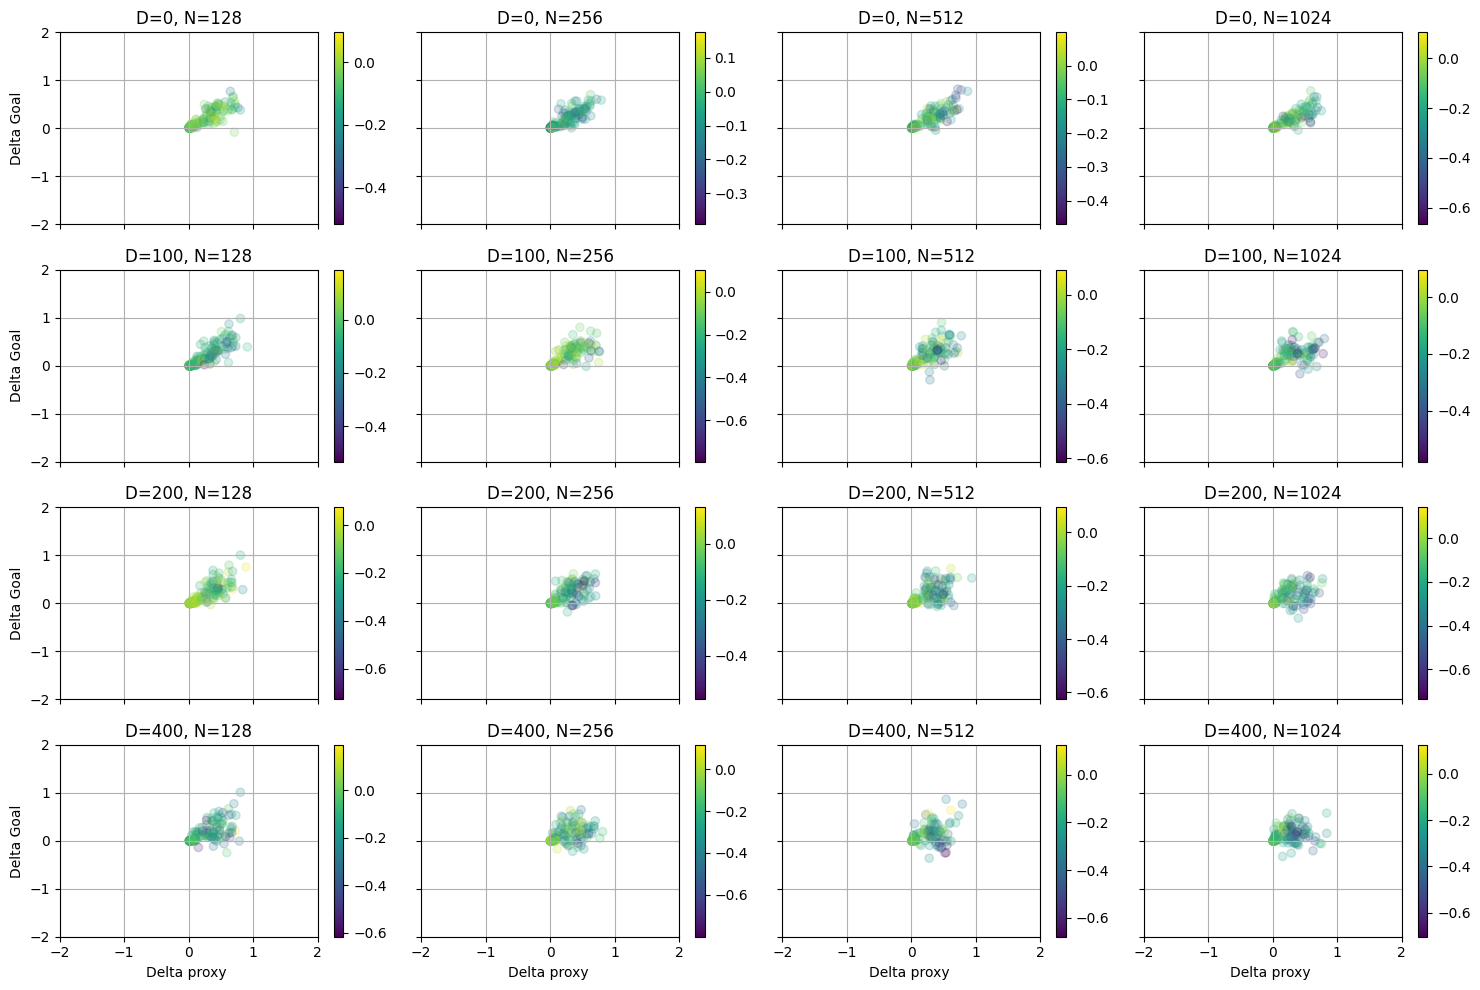

2400   -0.140542
2401   -0.062667
2402   -0.191535
2403   -0.078491
2404   -0.025677
          ...   
2555   -0.269622
2556   -0.157714
2557   -0.358407
2558   -0.544258
2559   -0.355039
Name: correlation_diff, Length: 160, dtype: float64


In [3]:
from scipy.optimize import curve_fit
import json
import numpy as np
import matplotlib.pyplot as plt
from itertools import product


def plot_deltagoal_vs_deltaproxcorrelation_along(df, param1, param2):
    ''' find all possible values of param1 and param2 in the dataframe df
        and plot the delta goal vs delta proxy for each combination of param1 and param2
    '''
    print("Beware, Na values for correlation_diff are ignored")
    param1_values = df[param1].unique()
    param2_values = df[param2].unique()
    param_combinations = list(product(param1_values, param2_values))
    print(len(param1_values), len(param2_values))
    fig, axes = plt.subplots(len(param1_values), len(param2_values), figsize=(15, 10), sharex=True, sharey=True)
    for (p1, p2) in param_combinations:
        sub_df = df[(df[param1] == p1) & (df[param2] == p2)]
        sub_df_no_na = sub_df[sub_df["correlation_diff"].notna()]
        sub_df_no_na = sub_df_no_na[sub_df_no_na["correlation_diff"] > -1.999]
        sub_df = sub_df_no_na
        
        xi = param1_values.tolist().index(p1)
        yi = param2_values.tolist().index(p2)
        ax = axes[xi, yi]

        # scale all colors to be between -1 and 1
        
        

        ax.scatter(sub_df["proxy_improvement"],sub_df["goal_improvement"], alpha = 0.2,c=sub_df["correlation_diff"], cmap='viridis')

        #remove transparency from colorbar
        cbar = plt.colorbar(ax.collections[0], ax=ax)
        cbar.solids.set_alpha(1)

        ax.set_title(f'{param1}={p1}, {param2}={p2}')
        if param2_values.tolist().index(p2) == 0:
            ax.set_ylabel('Delta Goal')
        if param1_values.tolist().index(p1) == len(param1_values)-1:
            #ax.set_xlabel('Delta goal in ideal case')
            ax.set_xlabel('Delta proxy ')

        ax.grid()
        ax.set_xlim(-2, 2)
        ax.set_ylim(-2, 2)
    plt.tight_layout()
    plt.show()
    print(sub_df["correlation_diff"])
    
plot_deltagoal_vs_deltaproxcorrelation_along(df, 'D', 'N')


Beware, Na values for correlation_diff are ignored
4 4


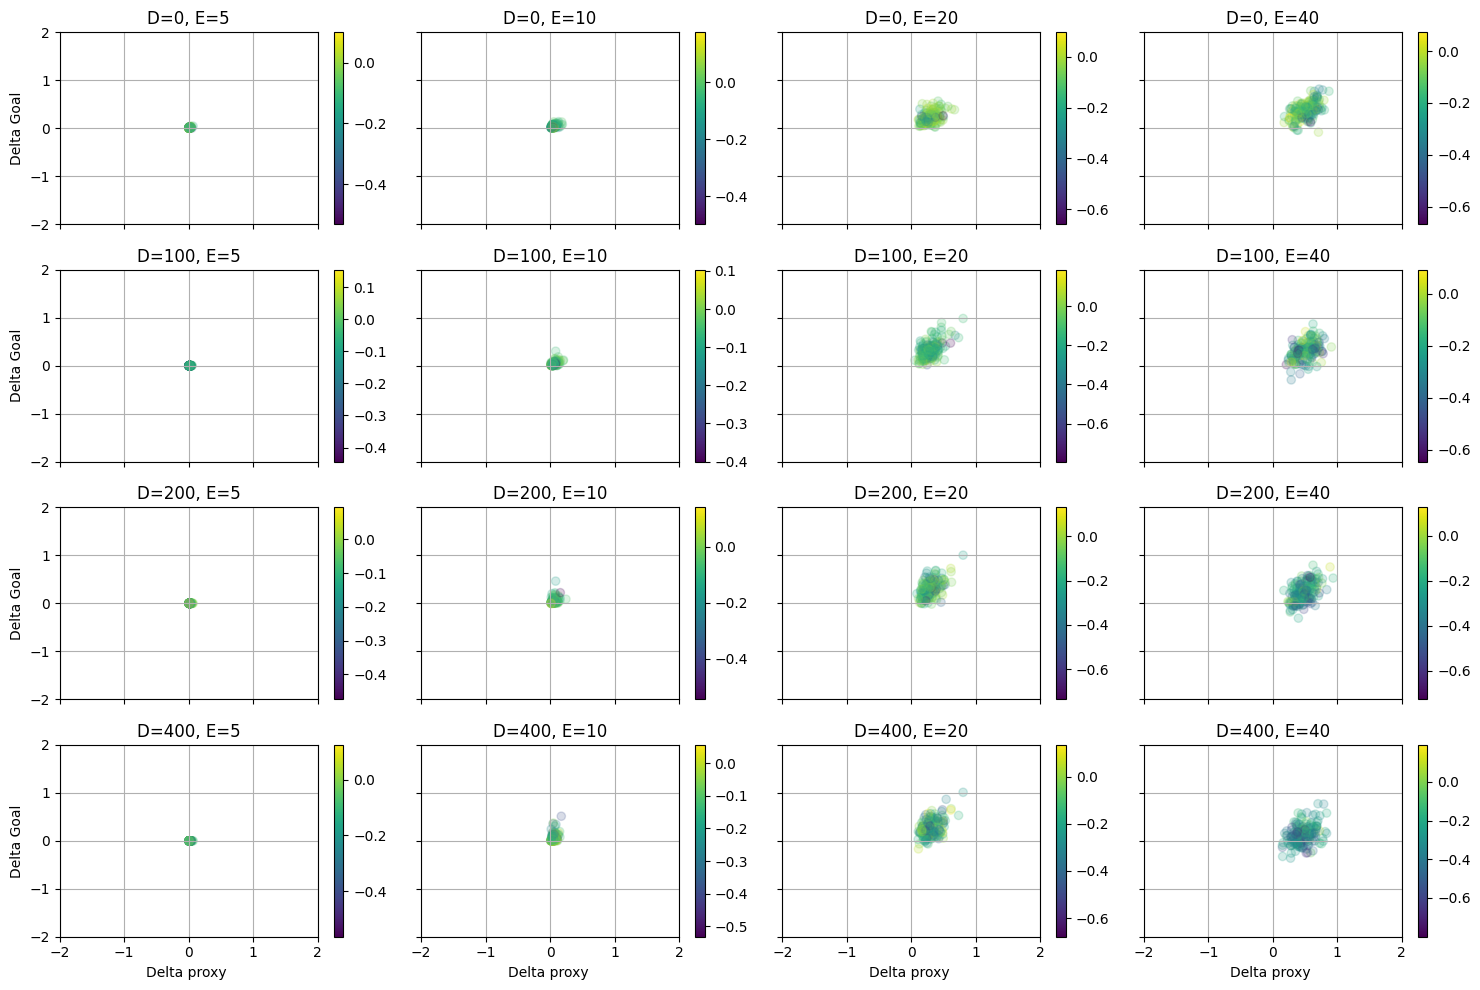

600    -0.226468
601     0.189763
602    -0.291372
603    -0.261133
604     0.011638
          ...   
2555   -0.269622
2556   -0.157714
2557   -0.358407
2558   -0.544258
2559   -0.355039
Name: correlation_diff, Length: 160, dtype: float64


In [4]:
plot_deltagoal_vs_deltaproxcorrelation_along(df, "D", 'E')


In [5]:
def plot_4params(df, param1, param2, param3, param4, option = '', filename = "test", cmax = None):
    ''' find all possible values of param1 and param2 in the dataframe df
        then for each combination of param1 and param2, make a scatter plot along the other two parameters
        and color the points according to param_for_color
    '''

    param1_values = df[param1].unique()
    param2_values = df[param2].unique()
    param3_values = df[param3].unique() 
    param4_values = df[param4].unique()
    cm = 1/2.54
    param_combinations = list(product(param1_values, param2_values))
    fig, axes = plt.subplots(len(param1_values), len(param2_values), figsize=(12*cm, 12*cm), sharex=True, sharey=True)
    #search for the maximum and minimum of param_for_color
    param_range = range(len(param_combinations))
    Ms = [np.zeros((len(param3_values), len(param4_values))) for k in param_range]
    

    
    for k in param_range:
        (p1, p2 )= param_combinations[param_range[k]]
        sub_df = df[(df[param1] == p1) & (df[param2] == p2)]
        xi = param1_values.tolist().index(p1)
        yi = param2_values.tolist().index(p2)
        ax = axes[xi, yi]


        # create all combinations of param3 and param4
        
        param3_values = sub_df[param3].unique() # reverse the order
        param4_values = sub_df[param4].unique()
        param3_4_combinations = list(product(param3_values, param4_values))

        for (p3, p4) in param3_4_combinations:
            subsub_df = sub_df[(sub_df[param3] == p3) & (sub_df[param4] == p4)]
            subsub_df = subsub_df[subsub_df.notna()]
            total = len(subsub_df)
            proxy_failure_df = subsub_df[(subsub_df["correlation_diff"] < 0)]
            prop_failure_prox = len(proxy_failure_df ) / total
            prop_failure_strong = len(proxy_failure_df[proxy_failure_df["goal_improvement"] < 0]) / total
            
            temp_weakdf = proxy_failure_df[proxy_failure_df["goal_improvement"] > 0]
            prop_failure_weak = len(temp_weakdf[temp_weakdf["proxy_improvement"] > temp_weakdf["goal_improvement"]]) / total
            prop_failure_benign = len(proxy_failure_df[proxy_failure_df["proxy_improvement"] < proxy_failure_df["goal_improvement"] ]) / total

            DeltaProx = np.mean(subsub_df["proxy_improvement"])
            DeltaGoal = np.mean(subsub_df["goal_improvement"])
            DeltaCorr = np.mean(subsub_df["correlation_diff"])
            if option =='strong':
                prop_failure = prop_failure_strong
            elif option == 'weak':
                prop_failure = prop_failure_weak
            elif option == 'benign':
                prop_failure = prop_failure_benign
            elif option == 'proxy_failure':
                prop_failure = prop_failure_prox
            elif option == 'DeltaProx':
                prop_failure = DeltaProx
            elif option == 'DeltaGoal':
                prop_failure = DeltaGoal
            elif option == 'DeltaCorr':
                prop_failure = DeltaCorr
            
            Ms[k][param3_values.tolist().index(p3), param4_values.tolist().index(p4)] = prop_failure

            
        # make a colormap of M
    if cmax is None:
        cmax = max([np.max(Ms[k]) for k in range(len(param_combinations))])
        cmin = min([np.min(Ms[k]) for k in range(len(param_combinations))])
    else:
        cmin = 0
        cmax = max(cmax, max([np.max(Ms[k]) for k in range(len(param_combinations))]))
    cmap = 'viridis'
    if option == "DeltaCorr":
        cmap = 'inferno_r'
    for k in param_range:
        (p1, p2 )= param_combinations[param_range[k]]
        xi = param1_values.tolist().index(p1)
        yi = param2_values.tolist().index(p2)
        ax = axes[xi, yi]
        ax.grid(False)
        c = ax.imshow(Ms[k], origin='lower', vmin=cmin, vmax=cmax, cmap=cmap, aspect='auto')

        #ax.scatter(grouped[param3], grouped[param4], alpha = 0.7, color = plt.cm.viridis((grouped[param_for_color] - min_color) / (max_color - min_color)))
        
        
        if param2_values.tolist().index(p2) == 0:
            ax.set_ylabel(param3)
            ax.set_yticks([0,1,2,3],param3_values) 
            ax.set_title(f'{param1}={p1}:                ', fontsize = 11, loc='right', pad = -5)
            if param1_values.tolist().index(p1) == 0:
                ax.set_title(f'{param1}={p1}:       {param2}={p2}', fontsize = 11, loc='right', pad = -5)
        elif param1_values.tolist().index(p1) == 0:
            ax.set_title(f'{param2}={p2}', fontsize = 11, loc='right', pad = -5)
        if param1_values.tolist().index(p1) == len(param1_values)-1:
            ax.set_xlabel(param4)
            ax.set_xticks([0,1,2,3],param4_values,rotation=90)
        ax.invert_yaxis()
        




    # add a common colorbar between the maximum and minimum of param_for_color
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=cmin, vmax=cmax))
    sm.set_array([])
    cax = fig.add_axes([0.92, 0.15, 0.02, 0.7])   # [left, bottom, width, height] in figure coords
    cbar = fig.colorbar(sm, cax=cax, orientation='vertical')
    #cbar = fig.colorbar(sm, ax=axes.ravel().tolist(), orientation='vertical', pad = 500)
    if option == 'proxy_failure':
        cbar.set_label("proportion of proxy failure", fontsize = 11)
    elif option[:5] == "Delta" :
        cbar.set_label("mean of "+ option+ "", fontsize = 11)
    else:
        cbar.set_label("proportion of "+ option+ " failure", fontsize = 11)
    matplotlib.rcParams['pdf.fonttype'] = 42
    matplotlib.rcParams['ps.fonttype'] = 42
    plt.subplots_adjust(wspace=0.2, hspace=0.2)
    plt.savefig(filename +".svg", dpi = 500)
    plt.show()
    return cmax
plot_4params(df, 'D', 'E', 'S', 'N', "proxy_failure", filename= "Matrixproxyfailure",cmax = 1)
plot_4params(df, 'D', 'E', 'S', 'N', "strong", filename= "Matrixstrongproxyfailure",cmax = 1)
plot_4params(df, 'D', 'E', 'S', 'N', "weak", filename= "Matrixweakproxyfailure",cmax = 1)
plot_4params(df, 'D', 'E', 'S', 'N', "benign", filename= "Matrixbenignproxyfailure",cmax = 1)
cmax = plot_4params(df, 'D', 'E', 'S', 'N', "DeltaProx", filename= "MatrixDeltaProx", cmax = 0)
plot_4params(df, 'D', 'E', 'S', 'N', "DeltaGoal", filename= "MatrixDeltaGoal", cmax = cmax)
plot_4params(df, 'D', 'E', 'S', 'N', "DeltaCorr", filename= "MatrixDeltaCorr")

KeyError: 'S'

In [ ]:
#plot_4params(df, 'S', 'N', 'D', 'E', True)

In [ ]:
from sklearn.cross_decomposition import PLSRegression

X = [[0., 0., 1.], [1.,0.,9.], [2.,0.,62], [1.,1.,119]]

y = [0.1, 0.9, 6.2, 11.9]

pls2 = PLSRegression(n_components=2)

pls2.fit(X, y)
PLSRegression()

y_pred = pls2.predict(X)
pls2.coef_
pls2.transform(X)

array([[-1.31878811,  0.11072015],
       [-0.81608175, -0.18799199],
       [ 0.27420347,  0.0952922 ],
       [ 1.8606664 , -0.01802035]])

In [ ]:
# create a new data base that groups collumns based of the parameters D E S N
unic = []
weak = False
param_list = ['D',"E","S","N"]
for k in param_list:
    unic.append( df[k].unique())

param_combinations = list(product(unic[0],unic[1],unic[2],unic[3] ))

Y = []
for k in range(len(param_combinations)):
    (p0,p1, p2,p3)= param_combinations[k]
    subsub_df = df[(df[param_list[0]] == p0) & (df[param_list[1]] == p1) &(df[param_list[2]] == p2) &(df[param_list[3]] == p3)]
    
    prop_failure = len(subsub_df[subsub_df["goal_improvement"] < -0.001]) / len(subsub_df) 
    if weak:
        subsub_df = subsub_df[subsub_df.notna()]
        prop_failure = len(subsub_df[(subsub_df["correlation_diff"] < 0) ]) / len(subsub_df)

    Y.append(prop_failure)

Y = np.asarray(Y)
Y = Y.reshape((-1,1))
Y_strong = Y

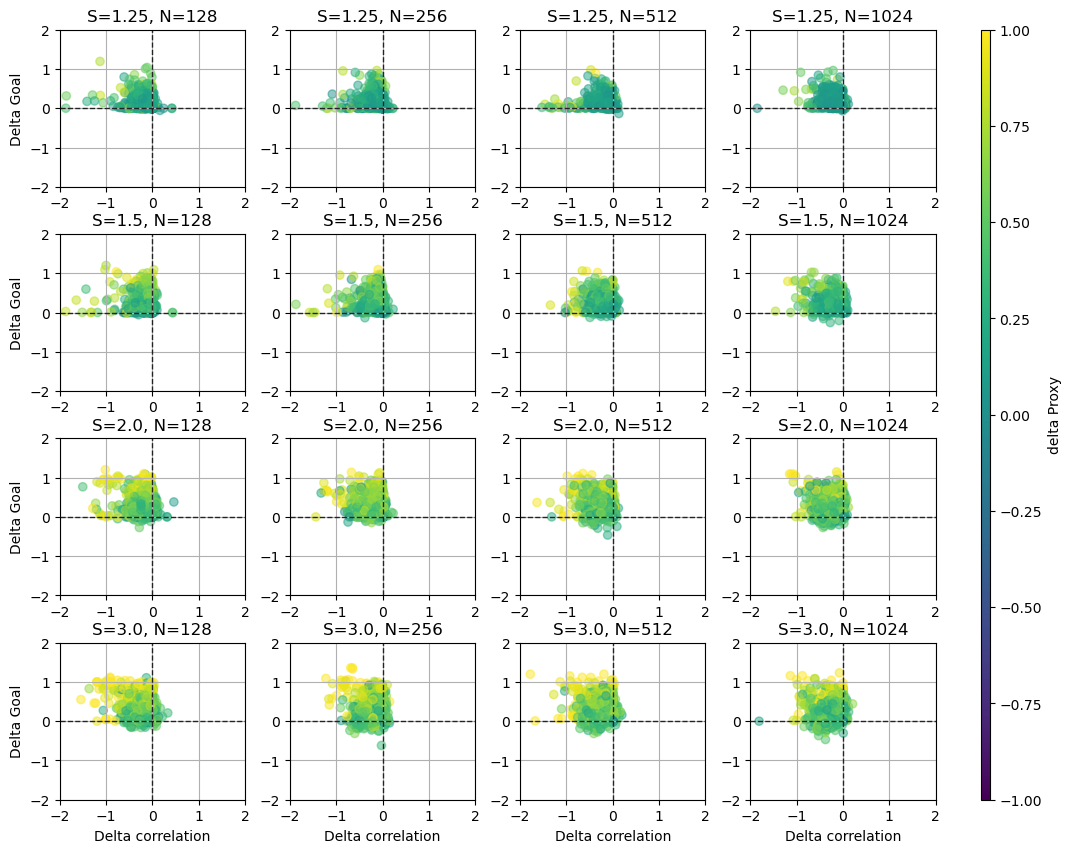

In [ ]:
from scipy.optimize import curve_fit
import json
import numpy as np
import matplotlib.pyplot as plt
from itertools import product
def plot_deltagoal_vs_deltaproxcorrelation_along(df, param1, param2):
    ''' find all possible values of param1 and param2 in the dataframe df
        and plot the delta goal vs delta proxy for each combination of param1 and param2.
        Colorcode the points by df['correlation_diff'].
    '''
    param1_values = df[param1].unique()
    param2_values = df[param2].unique()
    param_combinations = list(product(param1_values, param2_values))
    # Create figure with space for colorbar
    fig = plt.figure(figsize=(12, 10))
    # Create a grid layout that reserves space for the colorbar
    gs = fig.add_gridspec(len(param1_values), len(param2_values) + 1,
                         width_ratios=[1]*len(param2_values) + [0.05],
                         hspace=0.3, wspace=0.3)
    # Store scatter plot collections for colorbar
    scatter_collections = []
    for (p1, p2) in param_combinations:
        sub_df = df[(df[param1] == p1) & (df[param2] == p2)]
        xi = param1_values.tolist().index(p1)
        yi = param2_values.tolist().index(p2)
        ax = fig.add_subplot(gs[xi, yi])
        # scale colors in all subplots the same way
        scatter = ax.scatter(sub_df["correlation_diff"],sub_df["goal_improvement"], alpha = 0.5, c=sub_df['proxy_improvement'], cmap='viridis', vmin=-1, vmax=1)
        scatter_collections.append(scatter)
        na_df = sub_df[sub_df["correlation_diff"].isna()]
        #ax.scatter(na_df["goal_improvement"],[0]*len(na_df), color = "r", alpha = 0.3)
        ax.set_title(f'{param1}={p1}, {param2}={p2}')
        if param2_values.tolist().index(p2) == 0:
            ax.set_ylabel('Delta Goal')
        if param1_values.tolist().index(p1) == len(param1_values)-1:
            ax.set_xlabel('Delta correlation')
        ax.grid()
        ax.set_xlim(-2, 2)
        ax.set_ylim(-2, 2)
        # Add black lines for x=0 and y=0
        ax.axhline(y=0, color='black', linewidth=1, alpha=0.8, linestyle='--')
        ax.axvline(x=0, color='black', linewidth=1, alpha=0.8, linestyle='--')
    # Add colorbar in the reserved space
    if scatter_collections:
        # Create colorbar axis spanning all rows
        cbar_ax = fig.add_subplot(gs[:, -1])
        cbar = plt.colorbar(scatter_collections[0], cax=cbar_ax, label='delta Proxy')
        cbar.solids.set_alpha(1)  # Make colorbar non-transparent
    fig.savefig(f'delta_goal_vs_delta_proxy_correlation_{param1}_{param2}.pdf', bbox_inches='tight')
    plt.show()
plot_deltagoal_vs_deltaproxcorrelation_along(df, 'S', 'N')

In [ ]:
from scipy.optimize import curve_fit
import json
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import kurtosis
from itertools import product
def plot_deltagoal_vs_deltaproxcorrelation_along(df, param1, param2):
    ''' find all possible values of param1 and param2 in the dataframe df
        and plot the delta goal vs delta proxy for each combination of param1 and param2.
        Colorcode the points by df['correlation_diff'].
    '''
    param1_values = df[param1].unique()
    param2_values = df[param2].unique()
    param_combinations = list(product(param1_values, param2_values))
    # Create figure with space for colorbar
    fig = plt.figure(figsize=(12, 10))  
    # Create a grid layout that reserves space for the colorbar
    gs = fig.add_gridspec(len(param1_values), len(param2_values) + 1,
                         width_ratios=[1]*len(param2_values) + [0.05],
                         hspace=0.3, wspace=0.3)
    # Store scatter plot collections for colorbar
    scatter_collections = []
    for (p1, p2) in param_combinations:
        sub_df = df[(df[param1] == p1) & (df[param2] == p2)]
        xi = param1_values.tolist().index(p1)
        yi = param2_values.tolist().index(p2)
        ax = fig.add_subplot(gs[xi, yi])
        # scale colors in all subplots the same way
        #scatter = ax.scatter(sub_df["correlation_diff"],sub_df['proxy_improvement'] - sub_df["goal_improvement"], alpha = 0.5, c=sub_df['proxy_improvement'], cmap='viridis', vmin=-1, vmax=1)
        #scatter_collections.append(scatter)
        ax.hist(np.arctanh(sub_df['maxed_proxy_base']) - np.arctanh(sub_df["proxy_base"])  - np.arctanh(sub_df["optimal_goal_value"]) - np.arctanh(sub_df["goal_base"]), bins=20, color='blue', alpha=0.7)
        #write the kurtosis of the histogram in the top right corner
        kurt = kurtosis( np.arctanh(sub_df['maxed_proxy_value']) - np.arctanh(sub_df["proxy_base"])  - np.arctanh(sub_df["optimal_goal_value"]) - np.arctanh(sub_df["goal_base"]), fisher=True, bias=False)
        std = np.std(np.arctanh(sub_df['maxed_proxy_value']) - np.arctanh(sub_df["proxy_base"])  - np.arctanh(sub_df["optimal_goal_value"]) - np.arctanh(sub_df["goal_base"]))
        ax.text(0.95, 0.95, f'kurtosis={kurt:.2f},std={std:.2f}', transform=ax.transAxes, fontsize=8, verticalalignment='top', horizontalalignment='right')

        na_df = sub_df[sub_df["correlation_diff"].isna()]
        #ax.scatter(na_df["goal_improvement"],[0]*len(na_df), color = "r", alpha = 0.3)
        ax.set_title(f'{param1}={p1}, {param2}={p2}')
        if param2_values.tolist().index(p2) == 0:
            ax.set_ylabel('incidence')
        if param1_values.tolist().index(p1) == len(param1_values)-1:
            ax.set_xlabel('distortability')
        ax.grid()
        #ax.set_xlim(-2, 2)
        #ax.set_ylim(-2, 2)
        # Add black lines for x=0 and y=0
        ax.axhline(y=0, color='black', linewidth=1, alpha=0.8, linestyle='--')
        ax.axvline(x=0, color='black', linewidth=1, alpha=0.8, linestyle='--')
    # Add colorbar in the reserved space
    if scatter_collections:
        # Create colorbar axis spanning all rows
        cbar_ax = fig.add_subplot(gs[:, -1])
        cbar = plt.colorbar(scatter_collections[0], cax=cbar_ax, label='delta Proxy')
        cbar.solids.set_alpha(1)  # Make colorbar non-transparent
    fig.savefig(f'delta_goal_vs_delta_proxy_correlation_{param1}_{param2}.pdf', bbox_inches='tight')
    plt.show()
#plot_deltagoal_vs_deltaproxcorrelation_along(df, 'S', 'N')

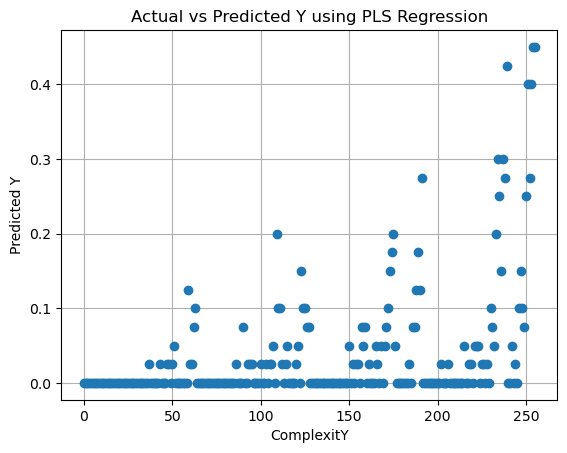

In [ ]:
a = Y_strong.flatten()

plt.plot([k for k in range(256)],a, 'o')
plt.xlabel('ComplexitY')
plt.ylabel('Predicted Y')
plt.title('Actual vs Predicted Y using PLS Regression')
plt.grid()
plt.show()

In [ ]:
# create a new data base that groups collumns based of the parameters D E S N
unic = []
weak = False
txttitle = "Strong"
if weak :
    txttitle = "Weak"

param_list = ['D',"E","S","N"]
for k in param_list:
    unic.append( df[k].unique())

param_combinations = list(product(unic[0],unic[1],unic[2],unic[3] ))

Ystronk = [[] for k in range(17)]
Yweak = [[] for k in range(17)]
for k in range(len(param_combinations)):
    (p0,p1, p2,p3)= param_combinations[k]
    complexity_class = sum([1+unic[i].tolist().index(param_combinations[k][i]) for i in range(4)])
    subsub_df = df[(df[param_list[0]] == p0) & (df[param_list[1]] == p1) &(df[param_list[2]] == p2) &(df[param_list[3]] == p3)]
    
    prop_failure = len(subsub_df[subsub_df["goal_improvement"] < -0.001]) / len(subsub_df) 

    subsub_df = subsub_df[subsub_df.notna()]
    prop_failur_weak = len(subsub_df[(subsub_df["correlation_diff"] < 0) ]) / len(subsub_df)

    Ystronk[complexity_class].append(prop_failure)
    Yweak[complexity_class].append(prop_failur_weak)

Y2stronk =  [np.mean(Ystronk[k]) for k in range(len(Ystronk))]
Y2stronk = Y2stronk[4:] # ignore the first four values
std2stronk = [np.sqrt((Y2stronk[k]) * (1 - (Y2stronk[k])) / len(Y2stronk))  for k in range(len(Y2stronk))]

Y2weak =  [np.mean(Yweak[k]) for k in range(len(Yweak))]
Y2weak = Y2weak[4:] # ignore the first four values
std2weak = [np.sqrt((Y2weak[k]) * (1 - (Y2weak[k])) / len(Y2weak))  for k in range(len(Y2weak))]



/home/paulbanse/anaconda3/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/paulbanse/anaconda3/lib/python3.12/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


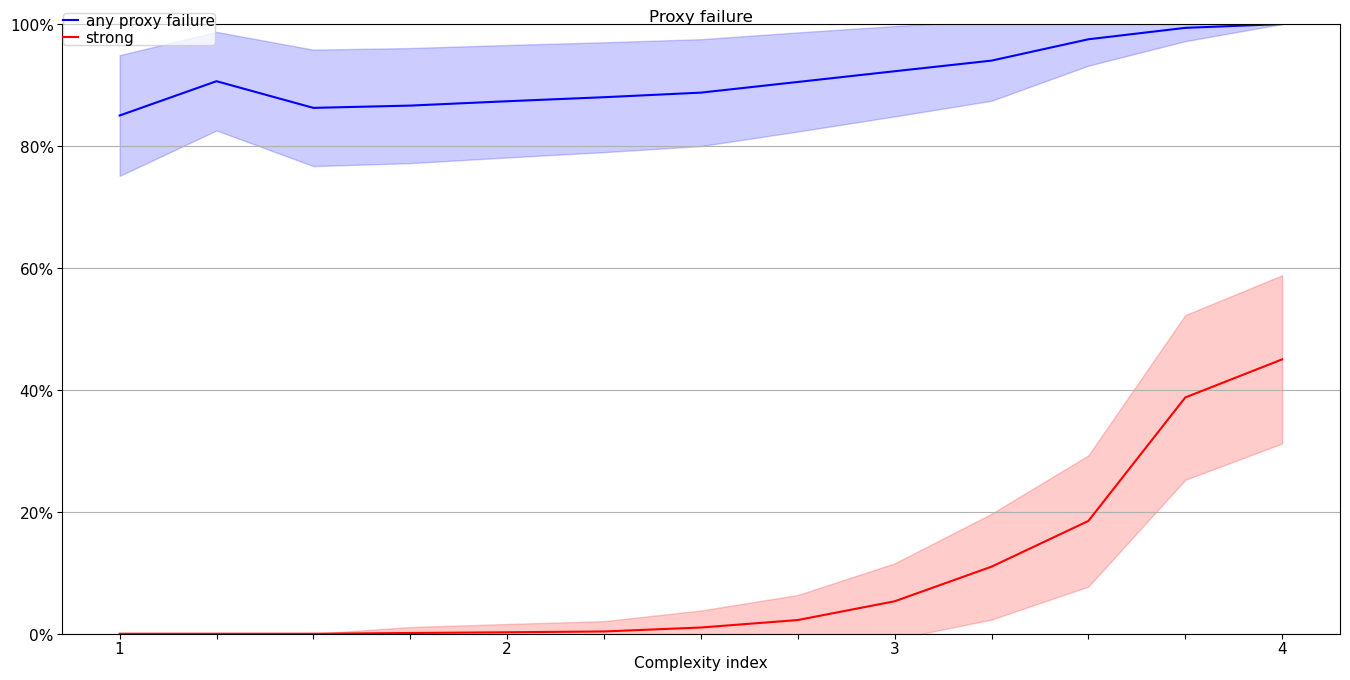

In [ ]:
from IPython.display import SVG, display
import io

a = Y_strong.flatten()
X_scaled = np.array(X)
X_scaled01 = (X_scaled - X_scaled.min(axis=0)) / (X_scaled.max(axis=0) - X_scaled.min(axis=0))

Xes = [k/4 for k in range(4,17)]
Xlab = [str(int(k/4))*(int(k/4)== k/4)+'' for k in range(4,17)]

cm = 1/2.54
fig, ax = plt.subplots(figsize=(17*2*cm, 17*cm),layout='compressed')
ax.yaxis.grid(True)
ax.xaxis.grid(False)
plt.fill_between(Xes, np.array(Y2stronk)-np.array(std2stronk), np.array(Y2stronk)+np.array(std2stronk), color='r', alpha=0.2)
plt.fill_between(Xes, np.array(Y2weak)-np.array(std2weak), np.array(Y2weak)+np.array(std2weak), color='b', alpha=0.2)
plt.plot(Xes, Y2weak, '-', color='b', label = 'any proxy failure')
plt.plot(Xes, Y2stronk, '-', color='r', label="strong")
plt.xlabel('Complexity index', fontsize = 11, labelpad=-1)
plt.title('Proxy failure', fontsize = 12,pad=2 )
plt.ylim(0,1)
plt.yticks([0,0.2,0.4,0.6,0.8,1], ['0%','20%','40%','60%','80%','100%'], fontsize = 11)
ax.tick_params(axis='y', which='major', pad=2)
ax.tick_params(axis='x', which='major', pad=2)
plt.xticks(Xes, labels = Xlab, fontsize = 11)

plt.legend(fontsize = 11, loc = 'upper left', bbox_to_anchor=(-0.005,1.03), borderpad=0,labelspacing=0.1, handlelength=1, handletextpad=0.5)
plt.savefig("test.svg")
plt.show()




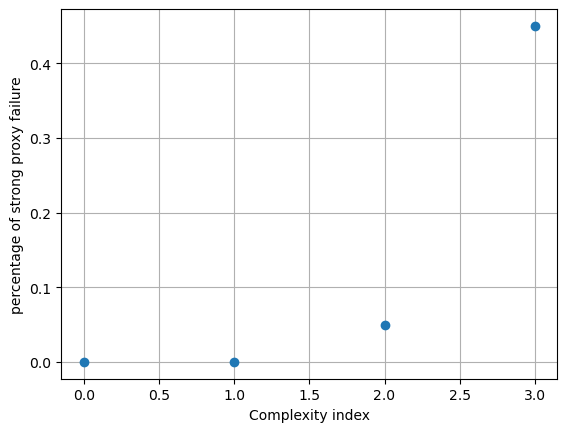

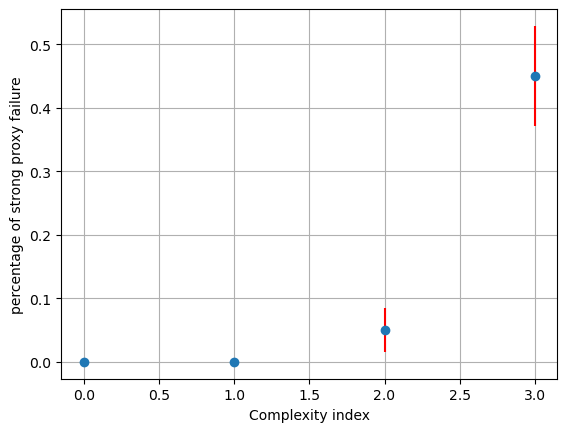

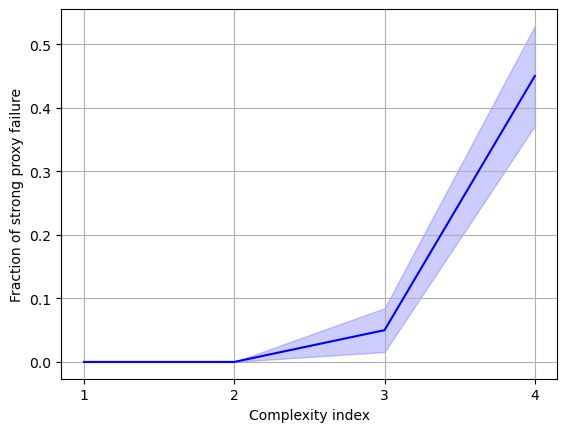

In [ ]:
# create a new data base that groups collumns based of the parameters D E S N
unic = []
weak = False
param_list = ['D',"E","S","N"]
for k in param_list:
    unic.append( df[k].unique())

param_combinations = list(product(unic[0],unic[1],unic[2],unic[3] ))

Y = [[] for k in range(len(param_combinations))]

Y3 =  []

for k in range(4):
    subsub_df = df[(df[param_list[0]] == unic[0][k]) & (df[param_list[1]] == unic[1][k]) &(df[param_list[2]] == unic[2][k]) &(df[param_list[3]] == unic[3][k])]
    
    prop_failure = len(subsub_df[subsub_df["goal_improvement"] < -0.001]) / len(subsub_df) 
    if weak:
        subsub_df = subsub_df[subsub_df.notna()]
        prop_failure = len(subsub_df[(subsub_df["correlation_diff"] < 0) ]) / len(subsub_df)

    Y3.append(prop_failure)

plt.plot( Y3, 'o')
plt.xlabel('Complexity index')
plt.ylabel('percentage of strong proxy failure')
plt.grid()
plt.show()

# compute 


import matplotlib.pyplot as plt
import numpy as np
means = [np.mean(Y3[k]) for k in range(len(Y3))]
stds = [np.sqrt((Y3[k]) * (1 - (Y3[k])) / 40)  for k in range(len(Y3))]
plt.errorbar([k for k in range(4)], means, yerr=stds, fmt='o', ecolor='r', capthick=2)
plt.xlabel('Complexity index')
plt.ylabel('percentage of strong proxy failure')
plt.grid()
plt.show()

# can you link the error bars into a area and the dots into a line  plot?
import matplotlib.pyplot as plt
import numpy as np
means = [np.mean(Y3[k]) for k in range(len(Y3))]
stds = [np.sqrt((Y3[k]) * (1 - (Y3[k])) / 40)  for k in range(len(Y3))]
plt.fill_between([k+1 for k in range(4)], np.array(means)-np.array(stds), np.array(means)+np.array(stds), color='b', alpha=0.2)
plt.plot([k+1 for k in range(4)], means, '-', color='b')
plt.xlabel('Complexity index')
plt.ylabel('Fraction of strong proxy failure')
plt.xticks([k+1 for k in range(4)])
plt.grid()
plt.show()


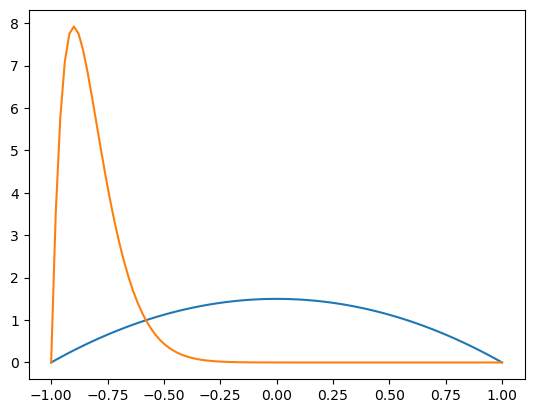

In [ ]:
# write a script to use beta distribution to make samples between 1 and -1

from scipy.stats import beta
import matplotlib.pyplot as plt
import numpy as np
a, b = 2,2  # shape parameters
x = np.linspace(0, 1, 100)
y = beta.pdf(x, a, b)
a2, b2 = 2,20
y2 = beta.pdf(x, a2, b2)
a3, b3 = 20,2
y3 = beta.pdf(x, a3, b3)
X = x * 2 - 1
plt.plot(X, y, label=f'Beta({a},{b})')
plt.plot(X, y2, label=f'Beta({a2},{b2})')
#plt.plot(X, y3, label=f'Beta({a3},{b3})')
plt.show()

In [ ]:
df.iloc[1,] 

n                                                                                128
trials                                                                            50
proxy_discard                                                                     50
goal_discard                                                                      50
measure_time                                                                      50
spectral_radius                                                                 1.25
alpha                                                                            0.1
avg_number_of_edges                                                              1.5
correlation_std                                                             0.539103
bin_indices_on_base_correlation    [14, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 2,...
maxed_goal_value                                                             0.00067
goal_base                                                        

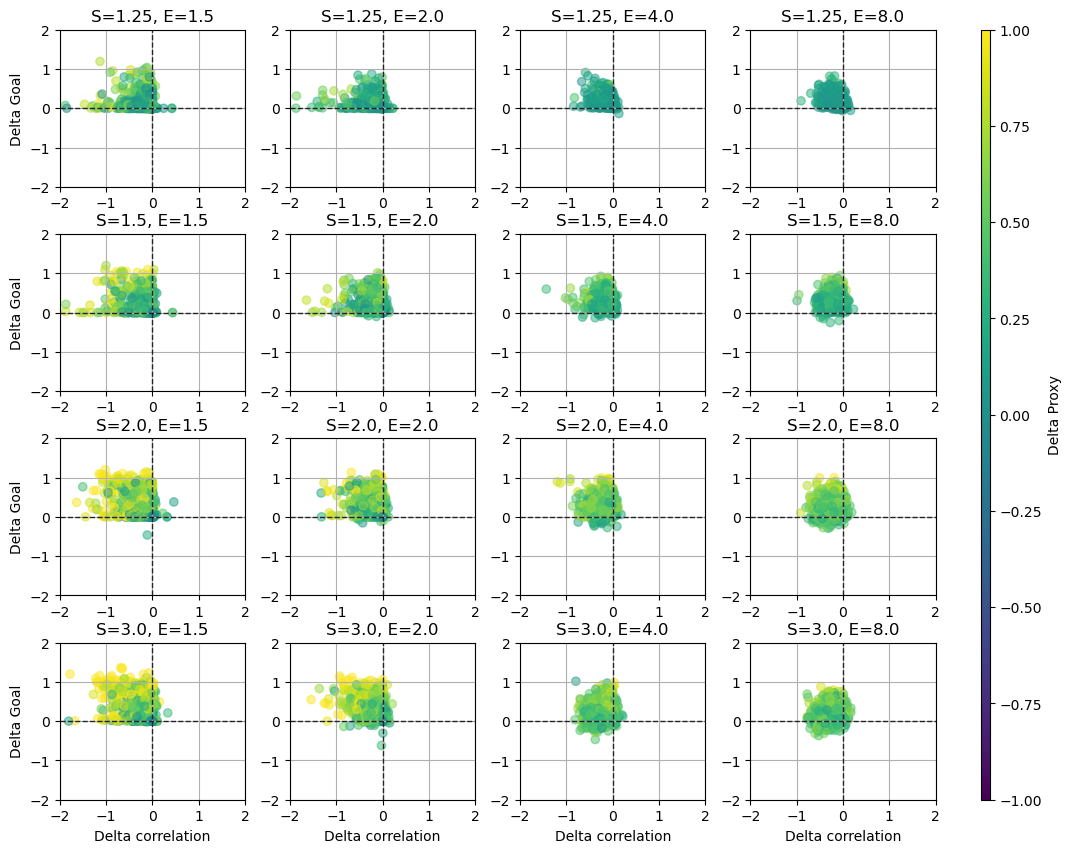

In [ ]:



                
from scipy.optimize import curve_fit
import json
import numpy as np
import matplotlib.pyplot as plt
from itertools import product
def plot2D_func(df, param1, param2,function_line):
    param1_values = df[param1].unique()
    param2_values = df[param2].unique()
    param_combinations = list(product(param1_values, param2_values))
    fig = plt.figure(figsize=(12, 10))
    gs = fig.add_gridspec(len(param1_values), len(param2_values) + 1,
                         width_ratios=[1]*len(param2_values) + [0.05],
                         hspace=0.3, wspace=0.3)

    collections = []
    for (p1, p2) in param_combinations:
        sub_df = df[(df[param1] == p1) & (df[param2] == p2)]
        xi = param1_values.tolist().index(p1)
        yi = param2_values.tolist().index(p2)
        ax = fig.add_subplot(gs[xi, yi])
        ax.set_xlim(-2, 2)
        ax.set_ylim(-2, 2)
        # scale colors in all subplots the same way
        scatter, X_axis,Y_axis,Z_axis = function_line(ax, sub_df)
        collections.append(scatter)
        na_df = sub_df[sub_df["correlation_diff"].isna()]
        #ax.scatter(na_df["goal_improvement"],[0]*len(na_df), color = "r", alpha = 0.3)
        ax.set_title(f'{param1}={p1}, {param2}={p2}')
        if param2_values.tolist().index(p2) == 0:
            ax.set_ylabel(Y_axis)
        if param1_values.tolist().index(p1) == len(param1_values)-1:
            ax.set_xlabel(X_axis)
        ax.grid()
        # Add black lines for x=0 and y=0
        ax.axhline(y=0, color='black', linewidth=1, alpha=0.8, linestyle='--')
        ax.axvline(x=0, color='black', linewidth=1, alpha=0.8, linestyle='--')
    # Add colorbar in the reserved space
    if Z_axis:
        # Create colorbar axis spanning all rows
        cbar_ax = fig.add_subplot(gs[:, -1])
        cbar = plt.colorbar(collections[0], cax=cbar_ax, label=Z_axis)
        cbar.solids.set_alpha(1)  # Make colorbar non-transparent
    fig.savefig(f'delta_goal_vs_delta_proxy_correlation_{param1}_{param2}.pdf', bbox_inches='tight')
    plt.show()

def function_scatter(ax, sub_df):
    scatter = ax.scatter(sub_df["correlation_diff"],sub_df["goal_improvement"], alpha = 0.5, c=sub_df['proxy_improvement'], cmap='viridis', vmin=-1, vmax=1)
    X_axis = 'Delta correlation'
    Y_axis = 'Delta Goal'
    Z_axis = 'Delta Proxy'
    return scatter, X_axis,Y_axis,Z_axis
plot2D_func(df, 'S', 'E', function_scatter)

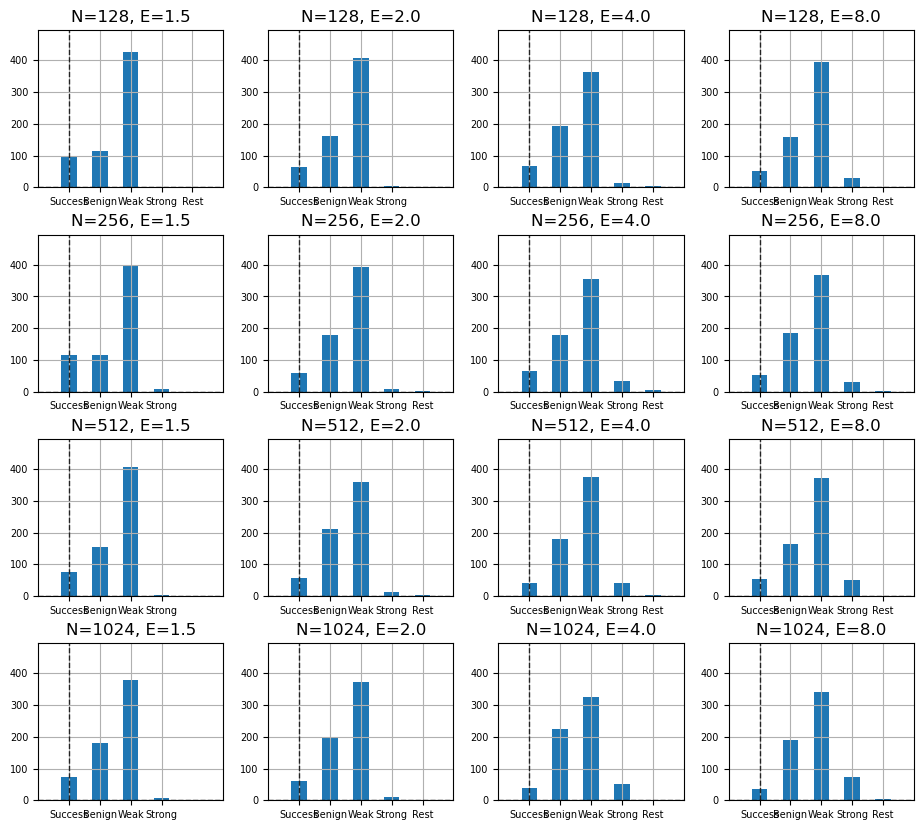

In [ ]:
def which_proxy(line):
    deltaCorr = line["correlation_on_max_proxy"] - line["correlation_base"]
    deltaGoal = line["maxed_goal_value"] - line["goal_base"]
    deltaProxy = line["maxed_proxy_value"] - line["proxy_base"]

    name_prox = pd.Series('Rest', index=line.index)  # default empty string

    cond_success = (deltaCorr > 0) & (deltaGoal > 0)
    cond_benign  = (deltaCorr < 0) & (deltaGoal > deltaProxy) & (deltaProxy > 0)
    cond_weak    = (deltaCorr < 0) & (deltaGoal < deltaProxy) & (deltaGoal > 0)
    cond_strong  = (deltaCorr < 0) & (deltaGoal < 0) & (deltaProxy > 0)

    name_prox.loc[cond_success] = 'Success'
    name_prox.loc[cond_benign]  = 'Benign'
    name_prox.loc[cond_weak]    = 'Weak'
    name_prox.loc[cond_strong]  = 'Strong'
    return name_prox
def function_hist(ax, sub_df):
    values = which_proxy(sub_df)
    order = [x for x in ['Success', 'Benign', 'Weak', 'Strong', 'Rest'] if x in values.unique()]
    validlist = values.value_counts()[order]
    categories = validlist.index
    counts = validlist.values
    scatter = ax.bar(categories, counts, width=0.5)
    X_axis = ''
    Y_axis = ''
    Z_axis = ''
    ax.set_xlim(-1,5)
    ax.set_ylim(0, 450*1.1)
    ax.tick_params(axis='both', which='major', labelsize=7)
    return scatter, X_axis,Y_axis,Z_axis
plot2D_func(df, 'N', 'E', function_hist)

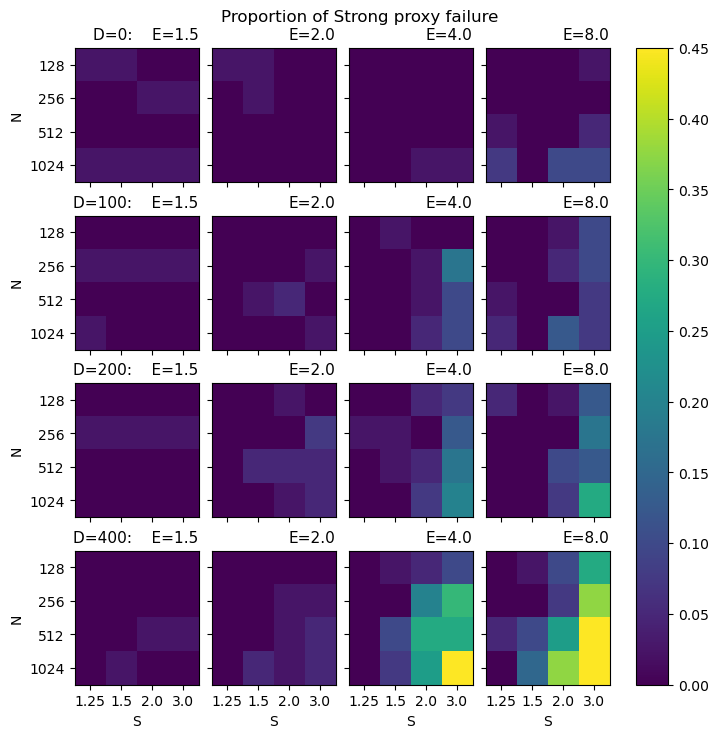

In [ ]:
def plot_heatmap_func(df, param1, param2,param3, param4, function_line, title = ""):
    ''' find all possible values of param1 and param2 in the dataframe df
        then for each combination of param1 and param2, make a scatter plot along the other two parameters
        and color the points according to param_for_color
    '''

    param1_values = df[param1].unique()
    param2_values = df[param2].unique()
    param3_values = df[param3].unique() 
    param4_values = df[param4].unique()
    cm = 1.5* 1/2.54
    param_combinations = list(product(param1_values, param2_values))
    fig, axes = plt.subplots(len(param1_values), len(param2_values), figsize=(12*cm, 12*cm), sharex=True, sharey=True, layout='compressed')
    #search for the maximum and minimum of param_for_color
    param_range = range(len(param_combinations))
    Ms = [np.zeros((len(param3_values), len(param4_values))) for k in param_range]

    
    for k in param_range:
        (p1, p2 )= param_combinations[param_range[k]]
        sub_df = df[(df[param1] == p1) & (df[param2] == p2)]
        xi = param1_values.tolist().index(p1)
        yi = param2_values.tolist().index(p2)
        ax = axes[xi, yi]


        # create all combinations of param3 and param4
        
        param3_4_combinations = list(product(param3_values, param4_values))
        param_range_34 = range(len(param3_4_combinations))
        for j in param_range_34:
            (p3, p4) = param3_4_combinations[param_range_34[j]]
            subsub_df = sub_df[(sub_df[param3] == p3) & (sub_df[param4] == p4)]
            
            prop = function_line(subsub_df)

            Ms[k][param3_values.tolist().index(p3), param4_values.tolist().index(p4)] = prop

        # make a colormap of M
        cmax = max([np.max(Ms[k]) for k in range(len(param_combinations))])
        cmin = min([np.min(Ms[k]) for k in range(len(param_combinations))])
    for k in param_range:
        (p1, p2 )= param_combinations[param_range[k]]
        xi = param1_values.tolist().index(p1)
        yi = param2_values.tolist().index(p2)
        ax = axes[xi, yi]
        ax.grid(False)
        c = ax.imshow(Ms[k], origin='lower', vmin=cmin, vmax=cmax, cmap='viridis', aspect='auto')

        #ax.scatter(grouped[param3], grouped[param4], alpha = 0.7, color = plt.cm.viridis((grouped[param_for_color] - min_color) / (max_color - min_color)))
        if param2_values.tolist().index(p2) == 0:
            ax.set_ylabel(param3)
            ax.set_yticks([0,1,2,3],param3_values) 
            ax.set_title(f'{param1}={p1}:    {param2}={p2}', fontsize = 11, loc='right')
        else:
            ax.set_title(f'{param2}={p2}', fontsize = 11, loc='right')
        if param1_values.tolist().index(p1) == len(param1_values)-1:
            ax.set_xlabel(param4)
            ax.set_xticks([0,1,2,3],param4_values)
        ax.invert_yaxis()

    sm = plt.cm.ScalarMappable(cmap='viridis', norm=plt.Normalize(vmin=cmin, vmax=cmax))
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=axes.ravel().tolist(), orientation='vertical')
    if title == "":
        title = "Proportion of " +function_line.__name__.replace("prop_","").capitalize() + " proxy failure"
    #cbar.set_label(title, fontsize = 11)
    fig.suptitle(title, fontsize = 12, y=1.02)
    matplotlib.rcParams['pdf.fonttype'] = 42
    matplotlib.rcParams['ps.fonttype'] = 42
    plt.savefig("test.pdf")
    plt.show()

def compute_deltas(line):
    deltaCorr = line["correlation_on_max_proxy"] - line["correlation_base"]
    deltaGoal = line["maxed_goal_value"] - line["goal_base"]
    deltaProxy = line["maxed_proxy_value"] - line["proxy_base"]
    return deltaCorr, deltaGoal, deltaProxy
def prop_strong(line):
    deltaCorr, deltaGoal, deltaProxy = compute_deltas(line)
    cond_strong  = (deltaCorr < 0) & (deltaGoal < 0) & (deltaProxy > 0)
    return cond_strong.sum() / len(line)

def prop_weak(line):
    deltaCorr, deltaGoal, deltaProxy = compute_deltas(line)
    cond_weak    = (deltaCorr < 0) & (deltaGoal < deltaProxy) & (deltaGoal > 0)
    return cond_weak.sum() / len(line)
def prop_benign(line):
    deltaCorr, deltaGoal, deltaProxy = compute_deltas(line)
    cond_benign  = (deltaCorr < 0) & (deltaGoal > deltaProxy) & (deltaProxy > 0)
    return cond_benign.sum() / len(line)
def prop_no(line):
    deltaCorr, deltaGoal, deltaProxy = compute_deltas(line)
    cond_success = (deltaCorr > 0) & (deltaGoal > 0)
    return cond_success.sum() / len(line)
plot_heatmap_func(df, 'D', 'E', 'N', 'S',  prop_strong)

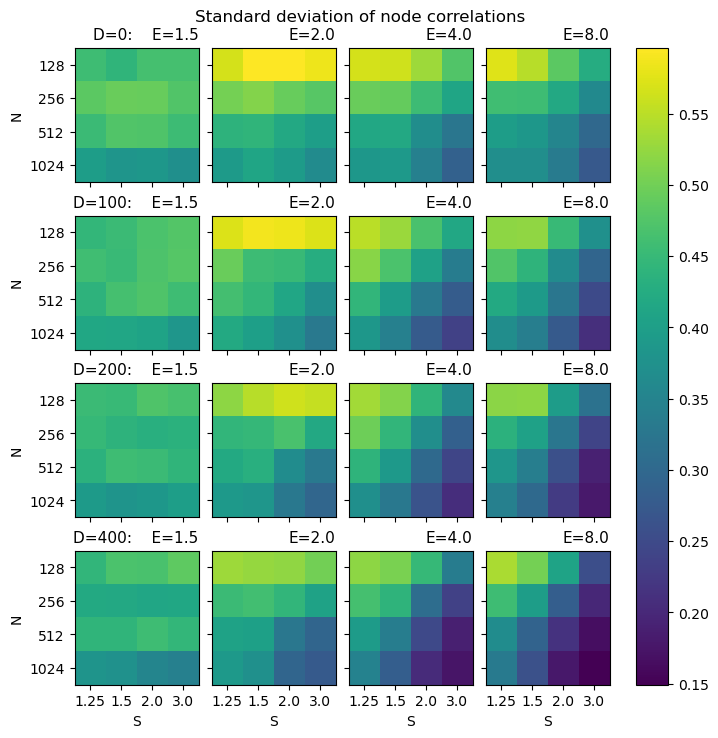

In [ ]:
def standard_deviation(line):
    std_list= []
    for index, row in line.iterrows():
        text = row['bin_indices_on_base_correlation'][1:-1]
        bin_vals = [int(k) for k in text.split(',')]
        values = [-1+(k+0.5)/(len(bin_vals))*2 for k in range(len(bin_vals))]
        std = np.sqrt(np.cov(values, aweights=bin_vals))
        std_list.append(std)
    return np.mean( std_list)

plot_heatmap_func(df, 'D', 'E', 'N', 'S', standard_deviation, title = "Standard deviation of node correlations")

In [ ]:
# --- Use PLS regression to derive orthogonal explaining vectors ---
from sklearn.preprocessing import StandardScaler
from sklearn.cross_decomposition import PLSRegression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
import numpy as np

# compute strong proxy proportion per parameter combination

def compute_strong_prop(grp):
    deltaCorr = grp["correlation_on_max_proxy"] - grp["correlation_base"]
    deltaGoal = grp["maxed_goal_value"] - grp["goal_base"]
    deltaProxy = grp["maxed_proxy_value"] - grp["proxy_base"]
    cond_strong = (deltaCorr < 0) & (deltaGoal < 0) & (deltaProxy > 0)
    cond_benign  = (deltaCorr < 0) & (deltaGoal > deltaProxy) & (deltaProxy > 0)
    return cond_strong.sum() / len(grp)

# build grouped dataframe

grouped = df.groupby(['D','E','S','N']).apply(compute_strong_prop).reset_index()
grouped = grouped.rename(columns={0:'prop_strong'})

# prepare features / target
features = ['D','E','S','N']
X = grouped[features].values
y = grouped['prop_strong'].values

# standardize the inputs
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

/tmp/ipykernel_3357/3999141675.py:21: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  grouped = df.groupby(['D','E','S','N']).apply(compute_strong_prop).reset_index()


In [ ]:
param_list

['D', 'E', 'S', 'N']

In [ ]:
X_scaled

array([[-1.18321596, -0.92821074, -1.02575529, -1.02575529],
       [-1.18321596, -0.92821074, -1.02575529, -0.65275337],
       [-1.18321596, -0.92821074, -1.02575529,  0.09325048],
       ...,
       [ 1.52127766,  1.6121555 ,  1.58525817, -0.65275337],
       [ 1.52127766,  1.6121555 ,  1.58525817,  0.09325048],
       [ 1.52127766,  1.6121555 ,  1.58525817,  1.58525817]])

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cross_decomposition import PLSRegression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import numpy as np

def repeated_pls(X, y, n_components=4, standardize=True):
    """Return list of component weight vectors (in original feature order, unit norm)
       and per-component R². Uses repeated PLS(1) with explicit deflation."""
    X = np.asarray(X)
    y = np.asarray(y).ravel()
    if standardize:
        scaler = StandardScaler()
        Xs = scaler.fit_transform(X)
    else:
        Xs = X.copy()

    X_work = Xs.copy()
    comps = []
    r2s = []
    for k in range(n_components):
        pls1 = PLSRegression(n_components=1)
        pls1.fit(X_work, y)
        # use x_rotations_ (maps X -> orthogonal scores)
        r = pls1.x_rotations_[:, 0].copy()
        r = -1*r if r[0] < 0 else r  # flip sign for consistency
        r /= np.linalg.norm(r)
        score = X_work @ r                  # orthogonal score (in X_work space)
        print(X_work.shape,"r")
        lr = LinearRegression().fit(score.reshape(-1, 1), y)
        r2 = r2_score(y, lr.predict(score.reshape(-1, 1)))
        comps.append(r)
        r2s.append(r2)
        # deflate X_work by removing projection along r
        X_work = X_work - np.outer(score, r)

    return comps, np.array(r2s)


repeated_pls(X_scaled,y)

(256, 4) r
(256, 4) r
(256, 4) r
(256, 4) r


([array([0.52759389, 0.52672159, 0.6165738 , 0.25307272]),
  array([ 0.31845066, -0.80363219,  0.43126542, -0.25840783]),
  array([ 0.27867879,  0.3683289 ,  0.88164891, -0.096784  ]),
  array([ 0.80951377,  0.56525371, -0.04144215, -0.15316085])],
 array([0.39437934, 0.        , 0.        , 0.        ]))

(256, 4) r
(256, 4) r
(256, 4) r
(256, 4) r


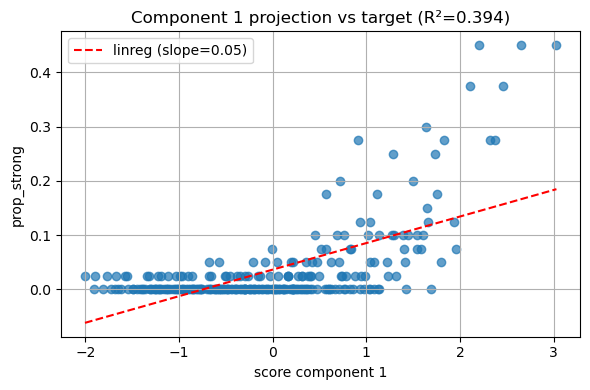

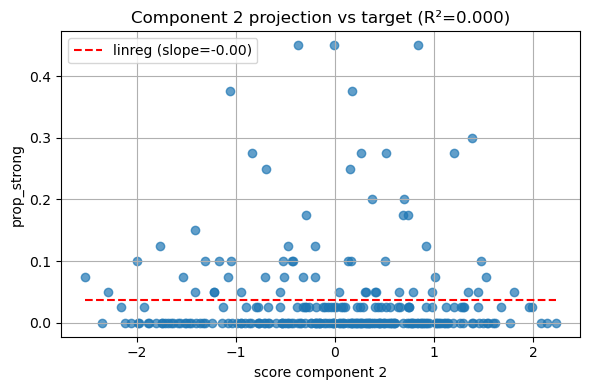

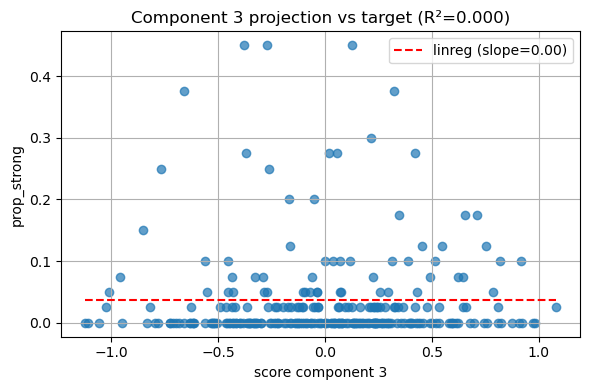

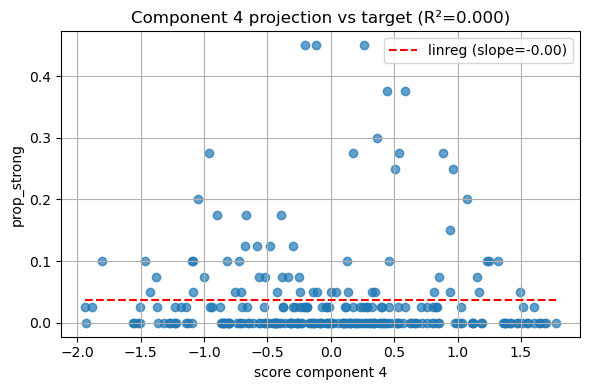

In [ ]:
# visualize scores along each PLS component
comps, r2s = repeated_pls(X_scaled, y)

# make plots of the projection (score) against the target for each component
X_work = X_scaled.copy()
for idx, comp in enumerate(comps):
    score = X_work @ comp
    plt.figure(figsize=(6,4))
    plt.scatter(score, y, alpha=0.7)
    # add linear regression line
    if len(score) > 1:
        m, b = np.polyfit(score, y, 1)
        xs = np.linspace(score.min(), score.max(), 100)
        plt.plot(xs, m*xs + b, color='red', linestyle='--',
                 label=f'linreg (slope={m:.2f})')
        plt.legend()
    plt.xlabel(f"score component {idx+1}")
    plt.ylabel("prop_strong")
    plt.title(f"Component {idx+1} projection vs target (R²={r2s[idx]:.3f})")
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    # deflate for next component
    X_work = X_work - np.outer(score, comp)
